# Transformer Models (BERT, GPT) for NLP
## AIAT 122 – Deep Learning

## Learning objectives
- Load BERT and get embeddings for a sentence (understanding).
- Load GPT-2 and generate a short text (generation).

## 🔗 Where this fits

**Builds on:** Course 07 (AIAT 121) — Unit 4, lesson 01 "Bridge: Attention and Transformers — Just Enough to Use Them" — it placed BERT and GPT on the transformer map; here you load both and see the difference in their outputs.

**Used later in:** Course 10 (AIAT 124) — Unit 2, lesson 02 "Fine-tuning Language Models".

---

**Where is this used in real life?** BERT powers search, classification, and NER; GPT powers chatbots and completion. **We use BERT for understanding** (bidirectional context) **and GPT for generation** (left-to-right); we use them instead of only RNNs because Transformers capture long-range dependencies in parallel and scale better.

**Prerequisites:** Basic PyTorch/transformers. Run `pip install transformers torch` if needed.

## Short theory
- **BERT:** Encoder-only; bidirectional; good for classification, NER, QA.
- **GPT:** Decoder-only; autoregressive; good for text generation.
- **Hugging Face:** Pre-trained models and tokenizers; we use them for embeddings and generation without training here.

**📌 Covers slide(s):** Optional — do after core notebooks 01–05 (no specific slide).


## Inputs & Outputs
**Inputs:** `transformers`, `torch`; pre-trained BERT and GPT-2 (downloaded on first run).  
**Dataset:** Real — pre-trained BERT and GPT-2 (Hugging Face; downloaded on first run).  
**Outputs:** BERT embedding shape for a sample sentence, and a short GPT-2 generated text. Run time: under ~5 min (download once).


In [1]:
# WHAT: install/import Hugging Face Transformers and load both BERT and GPT-2 classes.
# WHY: one library gives us an encoder (BERT) and a decoder (GPT-2) to compare side by side.
%pip install transformers torch -q
from transformers import BertTokenizer, BertModel, GPT2Tokenizer, GPT2LMHeadModel
import torch
print("✅ Imports OK.")


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


✅ Imports OK.


### Step 1: BERT – get embeddings for a sentence

In [2]:
# We use BERT for understanding (bidirectional); good for classification/embeddings
bert_tok = BertTokenizer.from_pretrained("bert-base-uncased")
bert = BertModel.from_pretrained("bert-base-uncased")
sentence = "Machine learning is a subset of artificial intelligence."
inputs = bert_tok(sentence, return_tensors="pt")
with torch.no_grad():
    out = bert(**inputs)
# [CLS] or mean of last_hidden_state = sentence embedding
emb = out.last_hidden_state
print("BERT output shape (batch, seq_len, hidden):", emb.shape)
print("Sentence embedding (mean over tokens) shape:", emb.mean(dim=1).shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT output shape (batch, seq_len, hidden): torch.Size([1, 11, 768])
Sentence embedding (mean over tokens) shape: torch.Size([1, 768])


### Step 2: GPT-2 – generate short text from a prompt

In [3]:
# We use GPT for generation (decoder-only, left-to-right)
gpt_tok = GPT2Tokenizer.from_pretrained("gpt2")
gpt_tok.pad_token = gpt_tok.eos_token
gpt = GPT2LMHeadModel.from_pretrained("gpt2")
prompt = "The future of AI is"
# Tokenize the prompt, generate 25 new tokens with sampling, then decode the IDs back to text.
inputs = gpt_tok(prompt, return_tensors="pt")
out = gpt.generate(inputs["input_ids"], max_new_tokens=25, do_sample=True, temperature=0.7, pad_token_id=gpt_tok.eos_token_id)
generated = gpt_tok.decode(out[0], skip_special_tokens=True)
print("Generated:", generated)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Generated: The future of AI is already being explored in a number of ways. One is by the introduction of social networks, which could be used to manage relationships


### Step 3: Show that "bidirectional" is a real property, not a label

So far BERT has printed a tensor shape and GPT-2 has printed a sentence. Neither output shows the thing this notebook is actually about: **BERT reads the words on both sides of a position, GPT-2 can only read the words before it.**

That is testable. Take one sentence with a hole in it and ask the *same* BERT to fill the hole twice — once with the rest of the sentence visible, once with everything after the hole deleted. Then ask GPT-2 to fill the same position, which it can only do from the left. Three distributions, one figure.

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(a) BERT, both sides visible  |  'The [MASK] barked loudly at the mailman.'
    dog=0.253  man=0.119  driver=0.050  guard=0.047  woman=0.040  boy=0.020  cat=0.015  clerk=0.012
(b) BERT, right side deleted  |  'The [MASK]'
    .=0.919  |=0.026  ;=0.026  !=0.013  ?=0.008  ...=0.000  -=0.000  '=0.000
(c) GPT-2, left side only  |  'The' -> next token
    ␣=0.014  the=0.010  "=0.008  ,=0.006  a=0.005  and=0.005  first=0.005  I=0.004


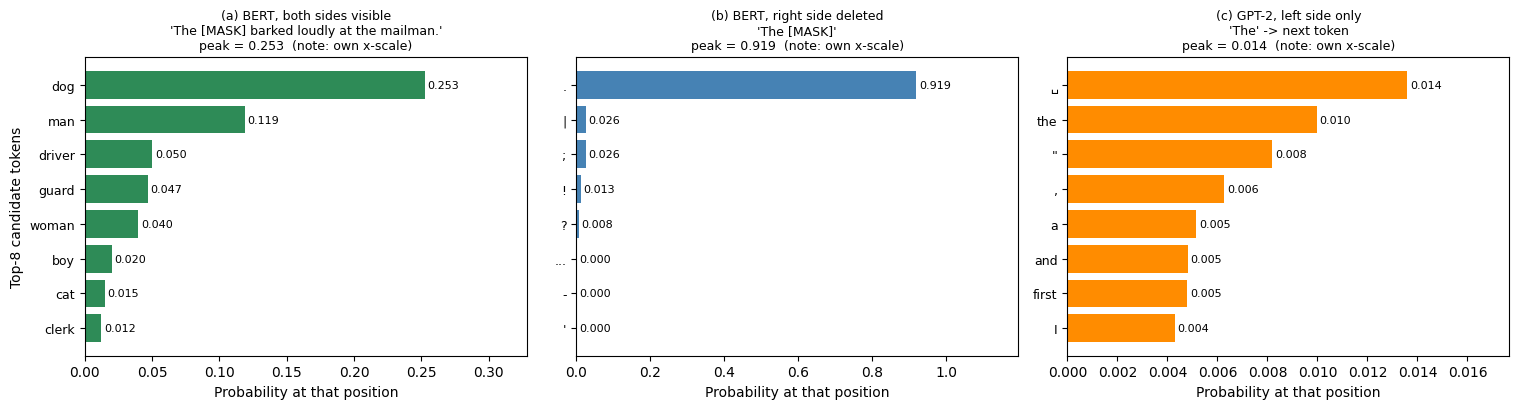

In [4]:
# WHAT: fill one masked position three ways - BERT with both sides, BERT with the left side only,
#       and GPT-2 (which has no other option) - and plot the three distributions.
# WHY: "bidirectional" and "autoregressive" are architecture words. This turns them into an
#      experiment whose result you can read off a bar chart.
import matplotlib.pyplot as plt
import numpy as np
from transformers import BertForMaskedLM

mlm = BertForMaskedLM.from_pretrained("bert-base-uncased")
mlm.eval()

full_ctx = "The [MASK] barked loudly at the mailman."
left_ctx = "The [MASK]"            # identical up to the mask; everything after it deleted
gpt_prompt = "The"                  # the same left context, in GPT-2's terms

def bert_top(sentence, k=8):
    """Top-k tokens BERT puts at the [MASK] position, with their probabilities."""
    enc = bert_tok(sentence, return_tensors="pt")
    pos = int((enc["input_ids"][0] == bert_tok.mask_token_id).nonzero()[0])
    with torch.no_grad():
        logits = mlm(**enc).logits[0, pos]
    probs = torch.softmax(logits, dim=-1)
    top = torch.topk(probs, k)
    return [bert_tok.convert_ids_to_tokens(int(i)) for i in top.indices], top.values.numpy()

def gpt_top(prompt, k=8):
    """Top-k tokens GPT-2 puts at the NEXT position - the only position it can fill."""
    enc = gpt_tok(prompt, return_tensors="pt")
    with torch.no_grad():
        logits = gpt(**enc).logits[0, -1]
    probs = torch.softmax(logits, dim=-1)
    top = torch.topk(probs, k)
    return [gpt_tok.decode([int(i)]).strip() or "\u2423" for i in top.indices], top.values.numpy()

panels = [
    (f"(a) BERT, both sides visible\n{full_ctx!r}", *bert_top(full_ctx), "seagreen"),
    (f"(b) BERT, right side deleted\n{left_ctx!r}", *bert_top(left_ctx), "steelblue"),
    (f"(c) GPT-2, left side only\n{gpt_prompt!r} -> next token", *gpt_top(gpt_prompt), "darkorange"),
]

for title, toks, ps, _ in panels:
    print(title.replace("\n", "  |  "))
    print("    " + "  ".join(f"{t}={v:.3f}" for t, v in zip(toks, ps)))

# NOTE: each panel gets its OWN x-scale. The three peaks differ by two orders of magnitude,
# so a shared axis would flatten two of the panels into nothing. Each title states its peak.
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2))
for ax, (title, toks, ps, col) in zip(axes, panels):
    y = np.arange(len(toks))[::-1]
    bars = ax.barh(y, ps, color=col)
    ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=2)
    ax.set_yticks(y); ax.set_yticklabels(toks, fontsize=9)
    ax.set_xlabel("Probability at that position")
    ax.set_title(f"{title}\npeak = {ps[0]:.3f}  (note: own x-scale)", fontsize=9)
    ax.set_xlim(0, ps[0] * 1.30)
axes[0].set_ylabel("Top-8 candidate tokens")
plt.tight_layout(); plt.show()

### 👁️ Read the figure — *the three panels have different x-scales; each title states its peak*

- **(a) BERT with the whole sentence visible.** The hole is filled with **`dog`** at about 0.25, ahead of `man`, `driver`, `guard`. The only word in that sentence that implies a dog is **`barked`**, and `barked` sits *after* the hole. BERT used it. That is what "bidirectional" buys, in one bar.
- **(b) The same model, the same position, with everything to the right deleted.** Now the top answer is a **full stop** at about 0.92, followed by more punctuation. Given only `"The"`, the most likely next thing is the end of the sentence, and BERT has no opinion at all about what kind of noun belongs there. **Same weights, same question — the right-hand context was the entire difference.**
- **(c) GPT-2 at the same position.** It is structurally in situation (b) *always*: a causal decoder can never see a token to its right. Its distribution is almost flat — the top candidate holds barely 1.4% — because "The" tells it nearly nothing. Note the x-scale: this panel's bars would be invisible on panel (b)'s axis.
- **The practical consequence, which is the reason both models exist.** For filling in, tagging, classifying or embedding a span you already have, you want (a) — an encoder. For continuing text you do not have yet, (a) is impossible, because the words to the right have not been written: you want (c), a decoder. This is the choice you make at work, and it is a property of the architecture, not a preference.

### Step 4: And "embedding" means a *contextual* embedding

The cell above printed `torch.Size([1, 11, 768])` — one 768-number vector per token. The word "vector for a token" sounds like a dictionary lookup, and for older methods (word2vec, GloVe) it was: one fixed vector per word, forever. BERT's is not. The same word in two different sentences gets two different vectors, and the difference is the sentence around it.

The cell below takes the word **bank** in two sentences that use it in two unrelated senses, plus the words **river** and **money** for reference, and measures how close the four vectors are.

Cosine similarity between contextual vectors:
  bank (river sense)   1.000  0.518  0.616  0.400
  bank (money sense)   0.518  1.000  0.495  0.630
  river                0.616  0.495  1.000  0.477
  money                0.400  0.630  0.477  1.000

'bank' vs 'bank' (same spelling, two senses): 0.518
'bank (river)' vs 'river': 0.616   |   'bank (river)' vs 'money': 0.400
'bank (money)' vs 'money': 0.630   |   'bank (money)' vs 'river': 0.495


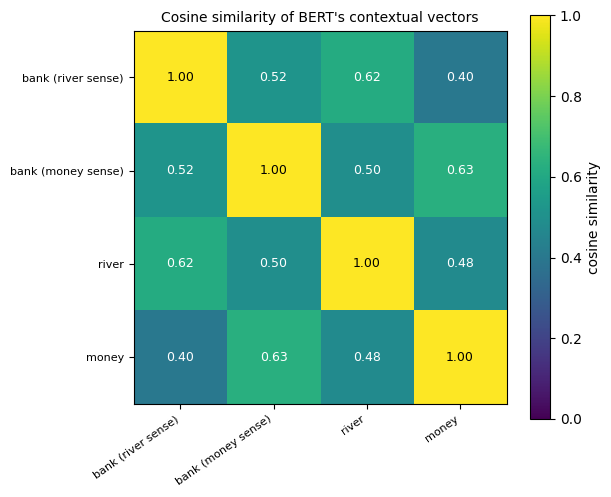

In [5]:
# WHAT: embed the SAME word in two different sentences and compare the vectors.
# WHY: "contextual embedding" is the whole reason BERT replaced word2vec. Two vectors for one
#      spelling, and which one it lands near, is the evidence.
probes = [
    ("bank (river sense)", "he sat on the bank of the river .", "bank"),
    ("bank (money sense)", "she deposited money at the bank .", "bank"),
    ("river", "the river was very wide .", "river"),
    ("money", "he counted the money carefully .", "money"),
]

vecs = []
for label, sent, target in probes:
    enc = bert_tok(sent, return_tensors="pt")
    toks = bert_tok.convert_ids_to_tokens(enc["input_ids"][0])
    pos = toks.index(target)
    with torch.no_grad():
        h = bert(**enc).last_hidden_state[0, pos]
    vecs.append(h.numpy())
V = np.stack(vecs)
Vn = V / np.linalg.norm(V, axis=1, keepdims=True)
S = Vn @ Vn.T                                   # cosine similarity between every pair

names = [pr[0] for pr in probes]
print("Cosine similarity between contextual vectors:")
for i, n in enumerate(names):
    print(f"  {n:20s} " + "  ".join(f"{S[i, j]:.3f}" for j in range(len(names))))
print(f"\n'bank' vs 'bank' (same spelling, two senses): {S[0, 1]:.3f}")
print(f"'bank (river)' vs 'river': {S[0, 2]:.3f}   |   'bank (river)' vs 'money': {S[0, 3]:.3f}")
print(f"'bank (money)' vs 'money': {S[1, 3]:.3f}   |   'bank (money)' vs 'river': {S[1, 2]:.3f}")

fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(S, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{S[i, j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if S[i, j] < 0.75 else "black")
ax.set_title("Cosine similarity of BERT's contextual vectors", fontsize=10)
fig.colorbar(im, ax=ax, label="cosine similarity")
plt.tight_layout(); plt.show()

### 👁️ Read the figure

Four contextual vectors, every pair compared. The diagonal is 1.00 by definition; read the off-diagonal cells.

- **`bank` and `bank` are only about 0.5 similar to each other.** Same spelling, same model, same layer — different vectors, because the sentences around them differ. A word2vec-style lookup table would put a **1.00** in that cell by construction; BERT does not have one vector for "bank" to look up.
- **And each one leans the right way.** `bank (river sense)` is closer to **river** than to **money**; `bank (money sense)` is closer to **money** than to **river**. Both gaps are about 0.1–0.2 and they point in opposite directions, which is exactly the disambiguation the sentence context is supposed to supply.
- **Honest reading of the absolute numbers:** do not treat 0.62 as "62% related". BERT's vectors are famously *anisotropic* — they occupy a narrow cone, so unrelated tokens still score fairly high cosine similarity. **The ordering of the cells is the evidence here, not their magnitude.**
- This is what the `torch.Size([1, 11, 768])` printed earlier actually contains: not eleven dictionary lookups, but eleven vectors each shaped by the other ten.

## 🌍 Real-World Worked Example — Character-Level Text Generator

**Industry context:**
- GitHub Copilot launched in June 2021 "powered by OpenAI Codex" (GitHub blog, 29 June 2021). It has since moved to a choice of models, and GitHub does not publish which one answers any given request — so do not attach a model name to it from memory.
- Models in this family emit one **token** at a time, conditioned on everything before it. Not one character, and not a whole line at once.
- Autocomplete on your phone is a much smaller version of the same next-symbol loop.

We build a **character-level language model** that learns to generate text token by token — the exact mechanism behind all LLMs.

In [6]:
# WHAT: train a character-level LSTM language model on a Shakespeare passage, then sample new text.
# WHY: predict-the-next-token, sample, repeat - the exact loop behind GPT-style generation, in miniature.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np

torch.manual_seed(42)
# ── Training text ────────────────────────────────────────────────────────────
text = (
    "to be or not to be that is the question whether tis nobler in the mind "
    "to suffer the slings and arrows of outrageous fortune or to take arms against "
    "a sea of troubles and by opposing end them to die to sleep no more and by "
    "a sleep to say we end the heartache and the thousand natural shocks that "
    "flesh is heir to tis a consummation devoutly to be wished to die to sleep"
)

# Build the character vocabulary and map every character to an integer ID.
chars  = sorted(set(text))
c2i    = {c:i for i,c in enumerate(chars)}
i2c    = {i:c for c,i in c2i.items()}
VOCAB  = len(chars)
enc    = [c2i[c] for c in text]

# Training pairs: 20 characters of context -> the character that follows.
SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(enc)-SEQ_LEN-1):
    X_list.append(enc[i:i+SEQ_LEN])
    y_list.append(enc[i+SEQ_LEN])
X_t = torch.tensor(X_list, dtype=torch.long)
y_t = torch.tensor(y_list, dtype=torch.long)

# ── LSTM Language Model ───────────────────────────────────────────────────
# The model: embed characters, run a 2-layer LSTM, predict the next character from the last hidden state.
class CharLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, 32)
        self.lstm  = nn.LSTM(32, 128, batch_first=True, num_layers=2)
        self.fc    = nn.Linear(128, VOCAB)
    def forward(self, x):
        out,_ = self.lstm(self.embed(x))
        return self.fc(out[:,-1,:])

model   = CharLM()
opt     = optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()

# 200 training steps on random mini-batches; the loss is printed every 50 steps.
for epoch in range(200):
    model.train()
    perm = torch.randperm(len(X_t))[:256]  # mini-batch
    loss = loss_fn(model(X_t[perm]), y_t[perm])
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch} — loss: {loss.item():.3f}")

# ── Text Generation (Greedy / Temperature Sampling) ──────────────────────
# Generation: feed the context, sample the next character from the softmax, append it, repeat.
def generate(seed_str, steps=80, temperature=0.8):
    model.eval()
    chars_out = list(seed_str)
    ctx = [c2i.get(c, 0) for c in seed_str[-SEQ_LEN:]]
    for _ in range(steps):
        inp = torch.tensor([ctx[-SEQ_LEN:]]).long()
        with torch.no_grad():
            # Temperature rescales the logits: lower = safer and more repetitive, higher = more random.
            logits = model(inp)[0] / temperature
        probs = torch.softmax(logits, 0).numpy()
        next_c = np.random.choice(len(probs), p=probs)
        chars_out.append(i2c[next_c])
        ctx.append(next_c)
    return ''.join(chars_out)

print("\n── Generated Text ──────────────────────────────────────────────")
print(generate("to be or not", steps=100))
print("\nThis is exactly how ChatGPT generates text — one token at a time.")

Epoch 0 — loss: 3.169


Epoch 50 — loss: 1.298


Epoch 100 — loss: 0.053


Epoch 150 — loss: 0.011



── Generated Text ──────────────────────────────────────────────
to be or notea ma ba sea sofe the tis thom and the thausand natusla nonsuma arin whethim tho qsleir t o sace sum

This is exactly how ChatGPT generates text — one token at a time.


## 🧩 Mini-exercise

**Try it:** Run BERT on a different sentence and print the embedding shape. Or generate a longer sequence with GPT-2 (e.g. max_length=50) and compare.

---

## Summary
**What you did:** Loaded BERT and got embedding shape for a sentence; loaded GPT-2 and generated a short continuation from a prompt.

**In real life you'd also:** Fine-tune BERT for classification, use GPT for longer generation with better decoding, and add task heads.

**The main idea:** BERT = understanding (bidirectional); GPT = generation (autoregressive); both are Transformer-based and pre-trained.

**Next:** `10_sentiment_analysis_translation_speech.ipynb` shows sentiment analysis with the pipeline API.

## 🔭 State of the field (2026)

Both halves of this notebook have current successors. On the encoder side, ModernBERT (arXiv 2412.13663) keeps BERT's objective but adds an 8,192-token context, 2 trillion training tokens and substantially lower memory use — a near drop-in replacement for `bert-base-uncased` in this workflow. On the decoder side the frontier stopped being dense: DeepSeek-V3 (arXiv 2412.19437) reaches frontier quality with a sparse mixture-of-experts network and multi-head latent attention, activating only a fraction of its parameters per token, with the training economics published.

**Why loading BERT and GPT-2 side by side is still the right exercise.** The choice this notebook forces — bidirectional encoder for understanding, causal decoder for generation — is the choice you actually make at work, and it is unchanged. A mixture-of-experts model is still a decoder; ModernBERT is still an encoder. Learn the two shapes and what each one's output actually is; the parameter counts will keep changing without you.


## 📚 References

1. Vaswani, A. et al. (2017). *Attention Is All You Need*. NeurIPS. https://arxiv.org/abs/1706.03762
2. Devlin, J., Chang, M.-W., Lee, K. & Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. NAACL. https://arxiv.org/abs/1810.04805
3. Brown, T. B. et al. (2020). *Language Models are Few-Shot Learners* (GPT-3). NeurIPS. https://arxiv.org/abs/2005.14165
4. Hoffmann, J. et al. (2022). *Training Compute-Optimal Large Language Models* (Chinchilla). NeurIPS. https://arxiv.org/abs/2203.15556

**Recent work (2024–2026)**

5. DeepSeek-AI (2024). *DeepSeek-V3 Technical Report*. arXiv. https://arxiv.org/abs/2412.19437 — where the GPT side went: a sparse mixture-of-experts model with multi-head latent attention at frontier quality, with its training economics published.
6. Warner, B. et al. (2024). *Smarter, Better, Faster, Longer: A Modern Bidirectional Encoder for Fast, Memory Efficient, and Long Context Finetuning and Inference* (ModernBERT). arXiv. https://arxiv.org/abs/2412.13663 — and where the BERT side went: the same encoder objective, 8,192-token context, 2 trillion training tokens, much lower memory.
